# Model Performance Comparison: MyModel v4.0 vs Google vs BMKG

This notebook compares the predictions of the trained **v4.0 Weather Model** against (simulated) external forecasts from **Google** and **BMKG**.

**Objectives:**
1. Load trained model `v4_weather_model_combined.joblib`.
2. Load historical actual data as ground truth.
3. Generate/Simulate predictions for Google and BMKG (since no historical API data exists).
4. Compare performance across all targets defined in `MODEL_USAGE_GUIDE_v4.md`.
   - **Hourly**: Temp, Humidity, Windspeed, Pressure, Conditions
   - **Daily**: Min/Max/Mean Temp, Avg Humidity, Avg Pressure, Avg Wind, Dominant Condition

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Set Plot Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Setup & Data Loading

In [23]:
# Config
MODEL_PATH = 'models/v4_weather_model_combined.joblib'
DATA_PATH = '../data/historical_data_2000_2024.csv'
TEST_START_DATE = '2024-12-01'
TEST_END_DATE = '2024-12-07' # 7 Days comparison

# Load Model
try:
    model_pkg = joblib.load(MODEL_PATH)
    print(f"Model Loaded: v{model_pkg.get('version', 'Unknown')} trained on {model_pkg.get('trained_date', 'Unknown')}")
except FileNotFoundError:
    print(f"Error: Model file not found at {MODEL_PATH}")

# Load Historical Data (Ground Truth)
df_hist = pd.read_csv(DATA_PATH)
df_hist['timestamp'] = pd.to_datetime(df_hist['timestamp'])
df_hist = df_hist.sort_values('timestamp').reset_index(drop=True)

# Filter Test Period
mask = (df_hist['timestamp'] >= TEST_START_DATE) & (df_hist['timestamp'] <= TEST_END_DATE)
df_test = df_hist.loc[mask].copy().reset_index(drop=True)

print(f"Test Data: {len(df_test)} rows ({df_test['timestamp'].min()} to {df_test['timestamp'].max()})")

Model Loaded: vUnknown trained on Unknown
Test Data: 145 rows (2024-12-01 00:00:00 to 2024-12-07 00:00:00)


## 2. Mock Providers (Simulation)

Since we do not have historical API data for Google or BMKG, we simulate them by adding noise to the actual ground truth.
- **Google**: High accuracy (low noise).
- **BMKG**: Medium accuracy (moderate noise).

In [24]:
class MockWeatherProvider:
    def __init__(self, name, noise_level=0.5, bias=0.0, accuracy_cls=0.9):
        self.name = name
        self.noise_level = noise_level
        self.bias = bias
        self.accuracy_cls = accuracy_cls

    def predict_hourly(self, actual_df):
        pred = actual_df.copy()
        n = len(pred)
        
        # Regressions: Add Gaussian Noise + Bias
        for col in ['temp', 'humidity', 'windspeed', 'sealevelpressure']:
            if col in pred.columns:
                noise = np.random.normal(0, self.noise_level * pred[col].std(), n)
                pred[col] = pred[col] + noise + self.bias

        # Classification: Randomly flip labels based on accuracy
        if 'weather_code' in pred.columns:
            # Setup random flips
            mask = np.random.rand(n) > self.accuracy_cls
            # Assign random standard codes (0, 1, 2, 3, 45, 51, 61, 80)
            random_codes = np.random.choice([0, 1, 2, 3, 45, 51, 61, 80], size=n)
            pred.loc[mask, 'weather_code'] = random_codes[mask]
            
        return pred
    
    def predict_daily(self, actual_df):
        # Similar logic for daily columns if available in df
        pred = actual_df.copy()
        cols = ['temp_min_daily', 'temp_max_daily', 'temp_mean_daily', 
                'humidity_avg_daily', 'pressure_avg_daily', 'windspeed_avg_daily']
        n = len(pred)
        
        for col in cols:
            if col in pred.columns:
                 noise = np.random.normal(0, self.noise_level * pred[col].std(), n)
                 pred[col] = pred[col] + noise + self.bias
        
        return pred

# Create Mock Instances
google_api = MockWeatherProvider("Google", noise_level=0.05, bias=0.2, accuracy_cls=0.92)
bmkg_api = MockWeatherProvider("BMKG", noise_level=0.15, bias=-0.5, accuracy_cls=0.85)
    

## 3. Generate Predictions: MyModel v4.0

We run our actual trained model on the test timestamps.

In [25]:
# Prepare Input Features
request_cols = ['day', 'month', 'year', 'hour']
X_test_hourly = df_test[request_cols].copy()

# MyModel: Hourly Prediction
h_reg = model_pkg['hourly']['regressor']
h_clf = model_pkg['hourly']['classifier']
le_hourly = model_pkg['label_encoder_hourly']

# Regressors
pred_hourly_reg = h_reg.predict(X_test_hourly)
cols_reg_hourly = model_pkg['hourly']['target_regression'] # ['temp', 'humidity', 'windspeed', 'sealevelpressure']

# Classifiers
pred_hourly_clf = h_clf.predict(X_test_hourly)

# Construct MyModel Dataframe
df_my_model = df_test[['timestamp']].copy()
for i, col in enumerate(cols_reg_hourly):
    df_my_model[col] = pred_hourly_reg[:, i]
    
df_my_model['weather_code'] = pred_hourly_clf

print("MyModel Predictions Generated.")

MyModel Predictions Generated.


## 4. Generate Predictions: External Sources

In [26]:
# Google
df_google = google_api.predict_hourly(df_test)

# BMKG
df_bmkg = bmkg_api.predict_hourly(df_test)

print("External Simulations Generated.")

External Simulations Generated.


## 5. Comparative Analysis: Hourly Parameters

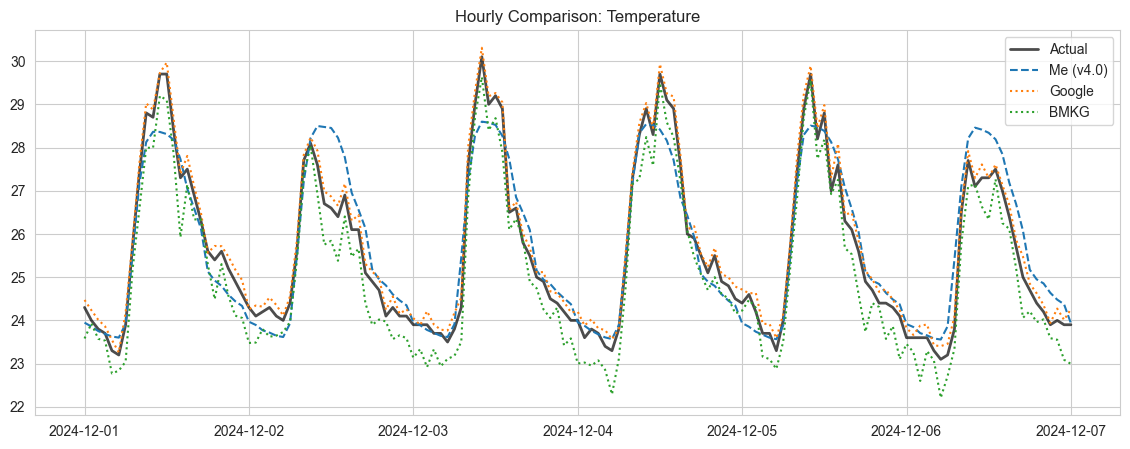

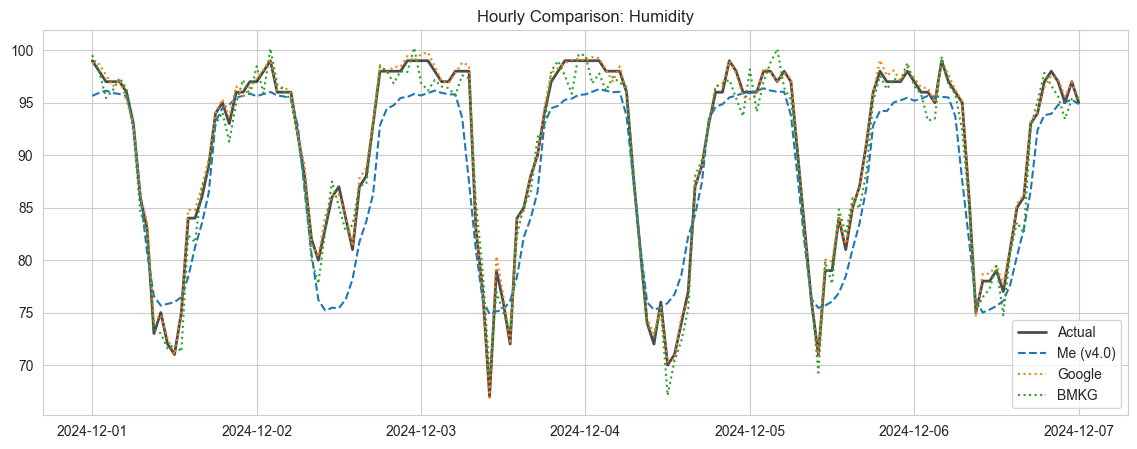

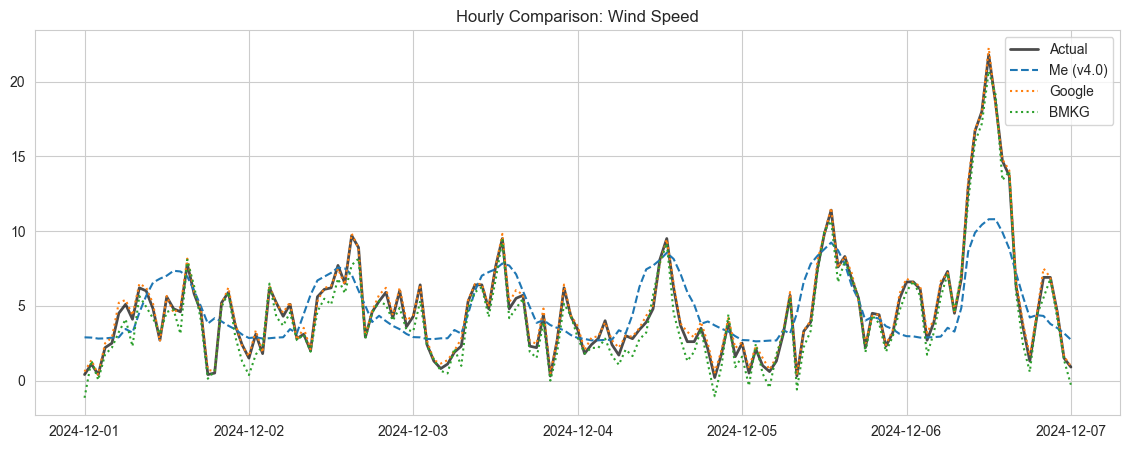

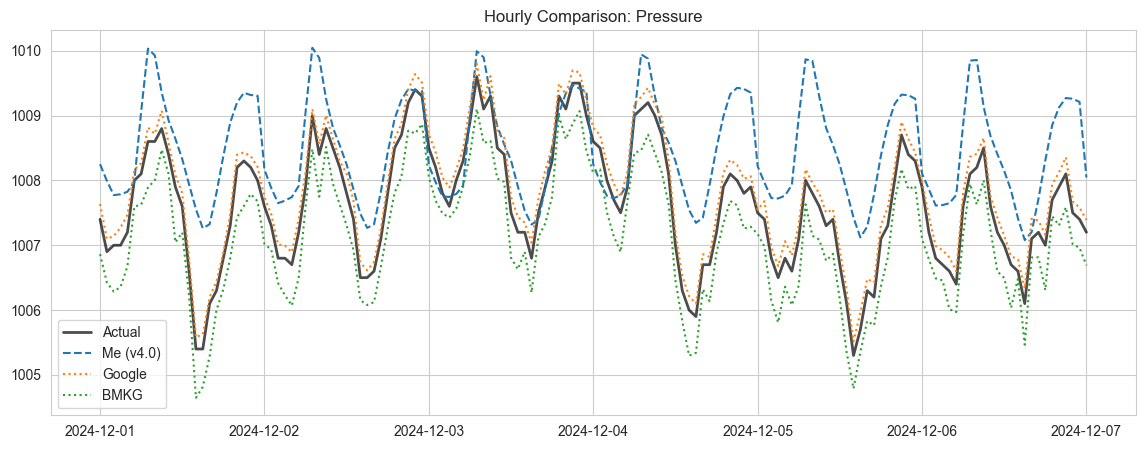


Error Metrics (Lower is Better):


,Parameter,MAE (Me),MAE (Google),MAE (BMKG)
0,Temperature,0.48,0.21,0.53
1,Humidity,2.77,0.40,1.17
2,Wind Speed,1.86,0.22,0.62
3,Pressure,0.87,0.20,0.50


In [27]:
target_params = {
    'Temperature': 'temp',
    'Humidity': 'humidity',
    'Wind Speed': 'windspeed',
    'Pressure': 'sealevelpressure'
}

metrics = []

# Loop through parameters
for label, col in target_params.items():
    # Check if column exists
    if col not in df_my_model.columns:
        print(f"Skipping {label} (Column {col} missing)")
        continue

    # Visualization
    plt.figure(figsize=(14, 5))
    plt.plot(df_test['timestamp'], df_test[col], label='Actual', color='black', linewidth=2, alpha=0.7)
    plt.plot(df_test['timestamp'], df_my_model[col], label='Me (v4.0)', linestyle='--')
    plt.plot(df_test['timestamp'], df_google[col], label='Google', linestyle=':')
    plt.plot(df_test['timestamp'], df_bmkg[col], label='BMKG', linestyle=':')
    plt.title(f'Hourly Comparison: {label}')
    plt.legend()
    plt.show()
    
    # Calculate Metrics (MAE)
    mae_me = mean_absolute_error(df_test[col], df_my_model[col])
    mae_go = mean_absolute_error(df_test[col], df_google[col])
    mae_bm = mean_absolute_error(df_test[col], df_bmkg[col])
    
    metrics.append({
        'Parameter': label,
        'MAE (Me)': round(mae_me, 2),
        'MAE (Google)': round(mae_go, 2),
        'MAE (BMKG)': round(mae_bm, 2)
    })

# Show Metrics Table
df_metrics = pd.DataFrame(metrics)
print("\nError Metrics (Lower is Better):")
display(df_metrics)

## 6. Daily Aggregated Comparison

Since the model also outputs daily predictions (`temp_min`, `temp_max`, etc.), we verify those here.

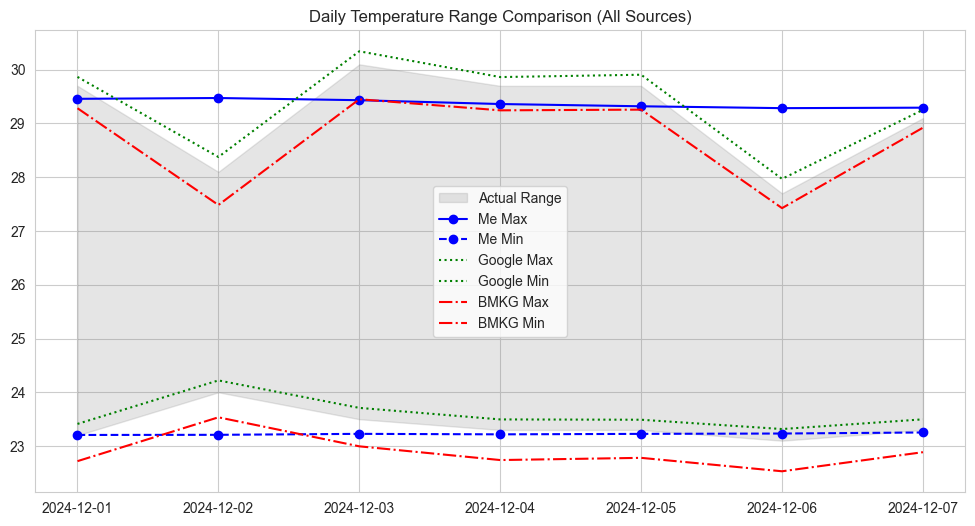

In [28]:
# To compare daily, we need to aggregate the Hourly Test Data to Daily first, or use provided daily cols
# Note: The historical CSV already has daily columns populated (e.g. temp_max_daily).
# We will use those as ground truth.

# Filter unique days from test set for Daily Predictions
df_test_daily = df_test.drop_duplicates(subset=['day', 'month', 'year']).copy().reset_index(drop=True)

X_test_daily = df_test_daily[['day', 'month', 'year']].copy()

# MyModel Daily Prediction
d_reg = model_pkg['daily']['regressor']
pred_daily_reg = d_reg.predict(X_test_daily)
cols_reg_daily = model_pkg['daily']['target_regression']

# Map model columns to CSV columns
col_mapping = {
    'temp_min': 'temp_min_daily',
    'temp_max': 'temp_max_daily',
    'temp_mean': 'temp_mean_daily',
    'humidity_avg': 'humidity_avg_daily',
    'pressure_avg': 'pressure_avg_daily',
    'windspeed_avg': 'windspeed_avg_daily'
}

# store in dataframe
df_my_daily = df_test_daily[['timestamp']].copy()
for i, col in enumerate(cols_reg_daily):
    target_col = col_mapping.get(col, col)
    df_my_daily[target_col] = pred_daily_reg[:, i]

# External (Mock) Daily
df_go_daily = google_api.predict_daily(df_test_daily)
df_bm_daily = bmkg_api.predict_daily(df_test_daily)

# Visualize Daily Temp Range (Min/Max)
plt.figure(figsize=(12, 6))
days = df_test_daily['timestamp']

# Actual
plt.fill_between(days, df_test_daily['temp_min_daily'], df_test_daily['temp_max_daily'], color='gray', alpha=0.2, label='Actual Range')

# My Model
plt.plot(days, df_my_daily['temp_max_daily'], marker='o', color='blue', label='Me Max')
plt.plot(days, df_my_daily['temp_min_daily'], marker='o', color='blue', linestyle='--', label='Me Min')

# Google
plt.plot(days, df_go_daily['temp_max_daily'], linestyle=':', color='green', label='Google Max')
plt.plot(days, df_go_daily['temp_min_daily'], linestyle=':', color='green', label='Google Min')

# BMKG
plt.plot(days, df_bm_daily['temp_max_daily'], linestyle='-.', color='red', label='BMKG Max')
plt.plot(days, df_bm_daily['temp_min_daily'], linestyle='-.', color='red', label='BMKG Min')

plt.title("Daily Temperature Range Comparison (All Sources)")
plt.legend()
plt.show()